IMPORTS & LOAD

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Load dataset
data = pd.read_csv('../data/cleaned_books.csv')

print("Dataset Shape:", data.shape)
print("\nColumns:\n", data.columns)

Dataset Shape: (3608, 10)

Columns:
 Index(['Book Name', 'Author', 'Number of Reviews_x', 'Price_x',
       'Number of Reviews_y', 'Price_y', 'Description', 'Listening Time',
       'Ranks and Genre', 'Rating'],
      dtype='object')


DATA CLEANING (EDA LEVEL)

In [2]:
# Handle missing values
data['Description'] = data['Description'].fillna("No description")

# Extract Genre
data['Genre'] = data['Ranks and Genre'].apply(
    lambda x: x.split(',')[0] if isinstance(x, str) else 'Unknown'
)

print("\nUnique Genres:", data['Genre'].nunique())


Unique Genres: 2


RATING DISTRIBUTION

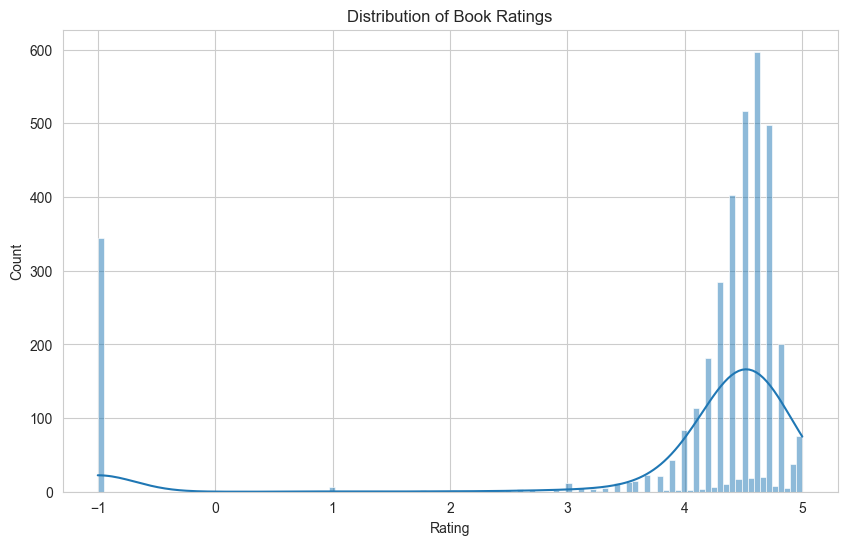

In [3]:
plt.figure(figsize=(10,6))
sns.histplot(data['Rating'], kde=True)
plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

TOP GENRES

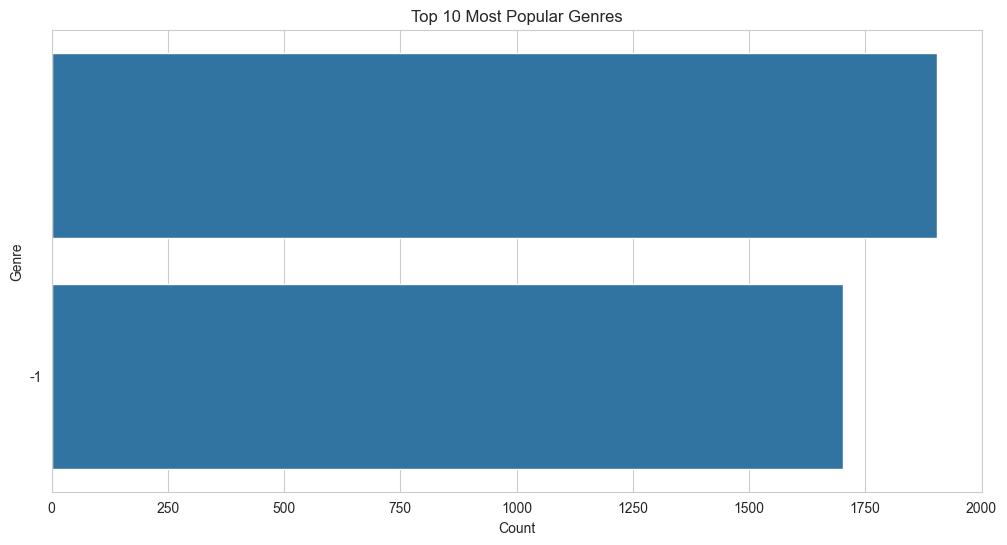

In [4]:
top_genres = data['Genre'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Most Popular Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

RATINGS VS REVIEWS

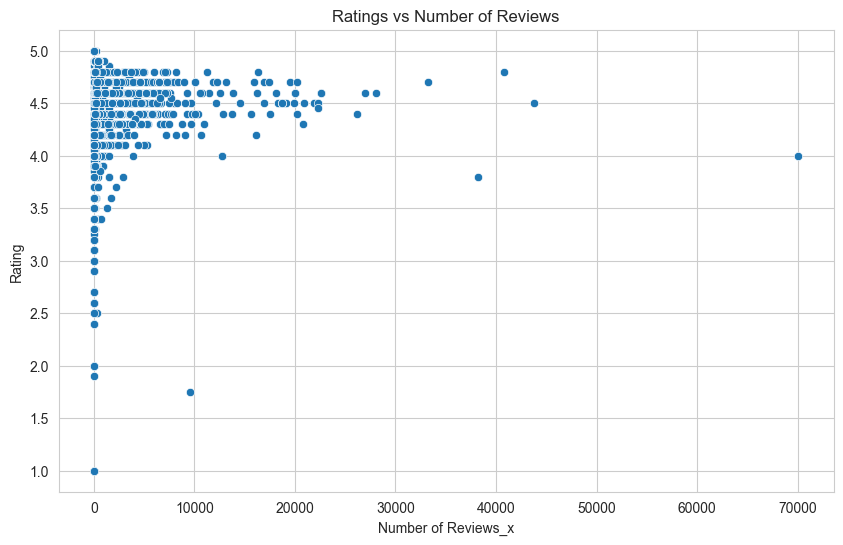

In [5]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=data,
    x='Number of Reviews_x',
    y='Rating'
)
plt.title("Ratings vs Number of Reviews")
plt.show()

CORRELATION HEATMAP (FIXED)

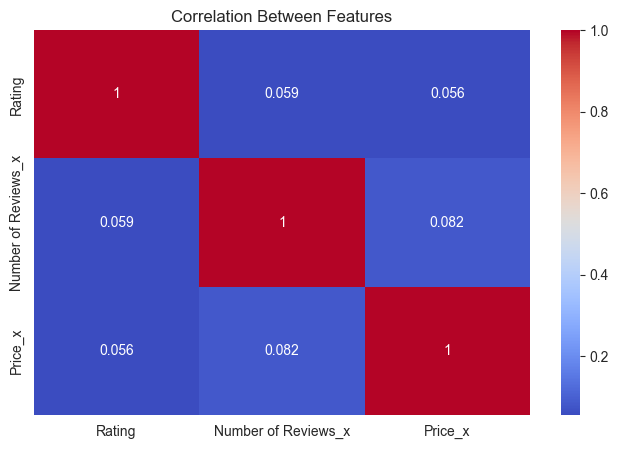

In [6]:
numeric_cols = ['Rating', 'Number of Reviews_x', 'Price_x']
corr = data[numeric_cols].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Between Features")
plt.show()

TOP AUTHORS (FIXED)

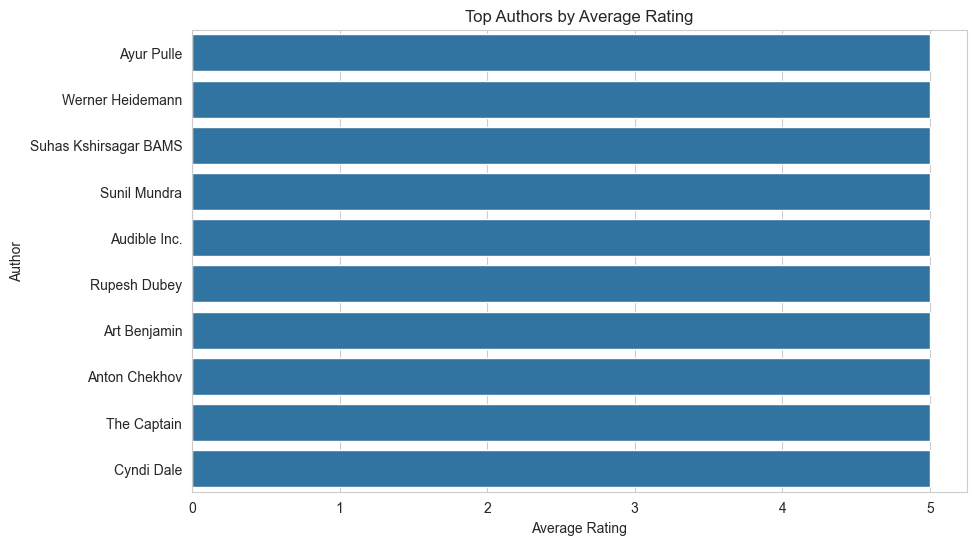

In [7]:
top_authors = (
    data.groupby('Author')['Rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(x=top_authors.values, y=top_authors.index)
plt.title("Top Authors by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Author")
plt.show()

HIDDEN GEMS (IMPORTANT FOR PROJECT)

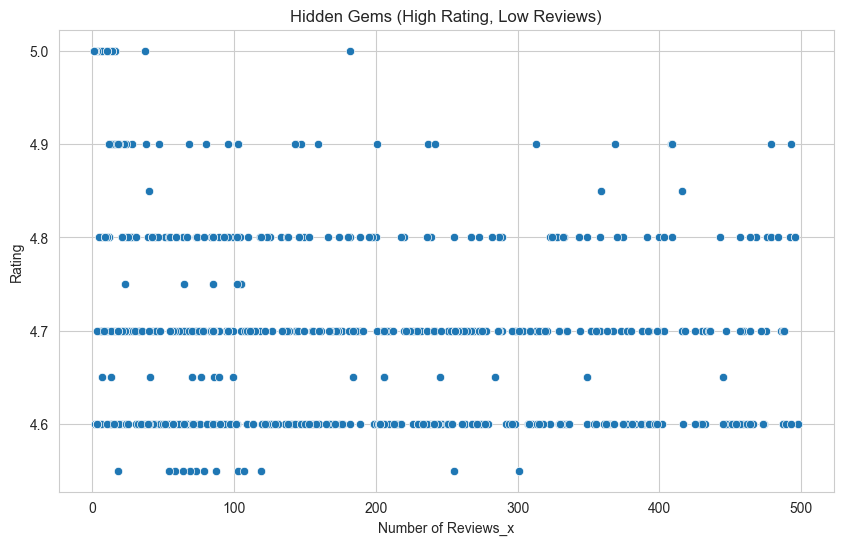

                                            Book Name              Author  \
0   Think Like a Monk: The Secret of How to Harnes...          Jay Shetty   
13                                        The Sandman         Neil Gaiman   
17         Sherlock Holmes: The Definitive Collection  Arthur Conan Doyle   
77                                      Wings of Fire     APJ Abdul Kalam   
80                                            Sapiens   Yuval Noah Harari   

    Rating  
0      4.9  
13     5.0  
17     5.0  
77     4.6  
80     4.6  


In [8]:
hidden_gems = data[
    (data['Rating'] > 4.5) &
    (data['Number of Reviews_x'] < 500)
]

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=hidden_gems,
    x='Number of Reviews_x',
    y='Rating'
)
plt.title("Hidden Gems (High Rating, Low Reviews)")
plt.show()

print(hidden_gems[['Book Name','Author','Rating']].head())

OPTIONAL (HIGH IMPACT ADDITION)

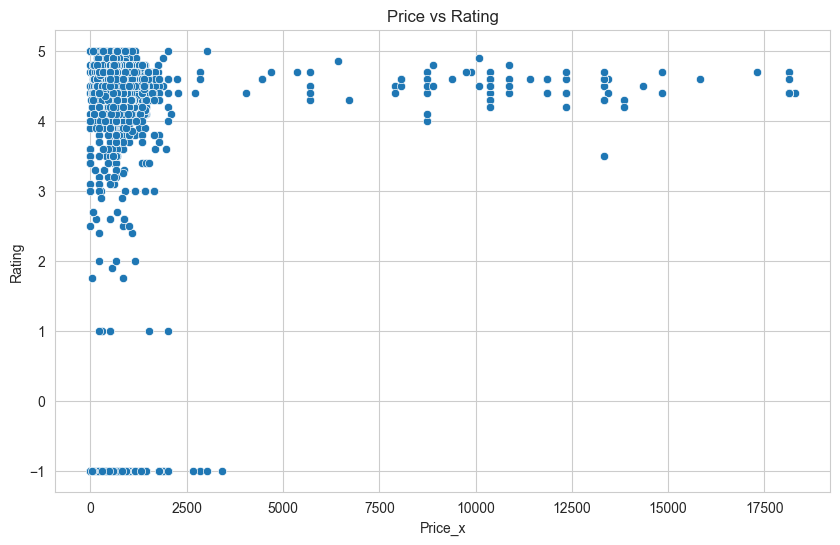

In [9]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=data, x='Price_x', y='Rating')
plt.title("Price vs Rating")
plt.show()